# Heart Disease Risk Prediction - Model Training

This notebook demonstrates the end-to-end process of training the Random Forest Classifier used in the HeartCare AI application.

## 1. Imports & Setup
Importing required libraries for data manipulation, machine learning, and visualization.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve,
                             accuracy_score)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

## 2. Data Loading
Loading the Cleveland Heart Disease dataset. The features include age, sex, chest pain type, blood pressure, cholesterol, etc.


In [ ]:
import pandas as pd

cols = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

# 1. Add 'encoding' as a parameter with a default value
def load_heart_file(filepath, encoding='utf-8'):
    rows = []
    # 2. Pass the encoding parameter to the open() function
    with open(filepath, 'r', encoding=encoding) as f:
        content = f.read()

    # Split all whitespace (handles spaces, newlines, mixed formatting)
    values = content.split()

    # Replace UCI missing value marker
    values = ['nan' if v in ['-9', '-9.0'] else v for v in values]

    # Group into rows of 14
    for i in range(0, len(values) - len(cols) + 1, len(cols)):
        row = values[i : i + len(cols)]
        if len(row) == len(cols):
            rows.append(row)

    df = pd.DataFrame(rows, columns=cols)

    # Convert all to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

# Your calls will now work perfectly
cleveland   = load_heart_file("cleveland.data", encoding='latin-1')
hungarian   = load_heart_file("hungarian.data", encoding='latin-1')
switzerland = load_heart_file("switzerland.data", encoding='latin-1')
va          = load_heart_file("long-beach-va.data", encoding='latin-1')

# Tag sources for transparency
cleveland['source']   = 'cleveland'
hungarian['source']   = 'hungarian'
switzerland['source'] = 'switzerland'
va['source']          = 'va'

heart_data = pd.concat([cleveland, hungarian, switzerland, va], ignore_index=True)

print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Cleveland   : {len(cleveland)}  rows")
print(f"Hungarian   : {len(hungarian)}  rows")
print(f"Switzerland : {len(switzerland)} rows")
print(f"VA          : {len(va)}  rows")
print(f"Total       : {len(heart_data)} rows")

DATASET SUMMARY
Cleveland   : 1615  rows
Hungarian   : 1596  rows
Switzerland : 667 rows
VA          : 1085  rows
Total       : 4963 rows


## 3. Data Preprocessing
Converting the target variable to binary (1 for disease, 0 for healthy) and dropping columns with excessive missing values.


In [ ]:
heart_data['target'] = (heart_data['target'] > 0).astype(int)

threshold = 0.4
before_cols = heart_data.shape[1]
heart_data = heart_data.loc[:, heart_data.isnull().mean() < threshold]
after_cols = heart_data.shape[1]
print(f"\nDropped {before_cols - after_cols} columns due to > 40% missing values.")

heart_data.fillna(heart_data.median(numeric_only=True), inplace=True)
heart_data.drop(columns='source', inplace= True)


print(f"Final Shape     : {heart_data.shape}")
print(f"Missing Values  : {heart_data.isnull().sum().sum()}")
print(f"n\Class Distribution :\n {heart_data['target'].value_counts()}")
print(f"\nFirst 5 Rows :\n {heart_data.head()}")



Dropped 0 columns due to > 40% missing values.
Final Shape     : (4963, 14)
Missing Values  : 0
n\Class Distribution :
 target
0    2586
1    2377
Name: count, dtype: int64

First 5 Rows :
      age  sex    cp  trestbps  chol    fbs  restecg  thalach  exang  oldpeak  \
0    1.0  0.0  63.0       1.0   1.0    1.0      2.0      1.0    1.0    145.0   
1   20.0  1.0   1.0       1.0   2.0    2.0      3.0     81.0    0.0      0.0   
2   10.5  6.0  13.0     150.0  60.0  190.0     90.0    145.0   85.0      0.0   
3  172.0  0.0   1.0       1.0   1.0    1.0      2.0      1.0    6.0      1.0   
4   81.0  0.0   1.0       1.0   1.0    1.0      1.0      1.0    1.0      1.0   

   slope     ca  thal  target  
0    1.0  233.0   2.0       1  
1    0.0    0.0   0.0       1  
2    0.0    2.3   3.0       0  
3    1.0    1.0   2.0       1  
4    1.0    1.0   1.0       1  


## 4. Feature Selection
Separating the features (X) from the target label (Y).


In [ ]:
X = heart_data.drop(columns='target')
Y = heart_data['target']

feature_cols = list(X.columns)
print(f"\nFeatures used: {feature_cols}")



Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 5. Train-Test Split
Splitting the data into training (80%) and testing (20%) sets using stratified sampling to maintain class distribution.


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print(f"\nTrain size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")



Train size : (3970, 13)
Test size  : (993, 13)


## 6. Handling Class Imbalance (SMOTE)
Using Synthetic Minority Over-sampling Technique (SMOTE) to balance the training data, ensuring the model does not become biased towards the majority class.


In [ ]:
print(f"\nBefore SMOTE: {dict(Y_train.value_counts())}")

smote = SMOTE(random_state=42)
X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)

print(f"After SMOTE : {dict(pd.Series(Y_train_bal).value_counts())}")



Before SMOTE: {0: np.int64(2069), 1: np.int64(1901)}
After SMOTE : {0: np.int64(2069), 1: np.int64(2069)}


## 7. Model Training
Training a Random Forest Classifier with balanced class weights and specific hyperparameters to prevent overfitting.


In [26]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_bal, Y_train_bal)

train_acc = model.score(X_train_bal, Y_train_bal)
test_acc  = model.score(X_test, Y_test)

print("\n" + "=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Train Accuracy : {train_acc:.3f}")
print(f"Test Accuracy  : {test_acc:.3f}")


MODEL PERFORMANCE
Train Accuracy : 0.871
Test Accuracy  : 0.829


## 8. Cross-Validation
Performing 5-fold Stratified Cross-Validation to evaluate the stability of the model across different data splits.


In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, Y, cv=cv, scoring='roc_auc')

print(f"\n5-Fold CV ROC-AUC : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Per-fold scores   : {[round(s,3) for s in cv_scores]}")


5-Fold CV ROC-AUC : 0.929 ± 0.004
Per-fold scores   : [np.float64(0.932), np.float64(0.921), np.float64(0.931), np.float64(0.933), np.float64(0.928)]


## 9. Model Evaluation
Evaluating the model on the unseen test set using ROC-AUC score and a detailed classification report.


In [28]:
Y_pred      = model.predict(X_test)
Y_pred_prob = model.predict_proba(X_test)[:, 1]

print(f"\nROC-AUC Score : {roc_auc_score(Y_test, Y_pred_prob):.3f}")
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred, target_names=['Healthy', 'Diseased']))



ROC-AUC Score : 0.918

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.85      0.82      0.83       517
    Diseased       0.81      0.84      0.82       476

    accuracy                           0.83       993
   macro avg       0.83      0.83      0.83       993
weighted avg       0.83      0.83      0.83       993



## 10. Visualizations
Plotting the Confusion Matrix, ROC Curve, and Precision-Recall Curve to visually assess model performance.


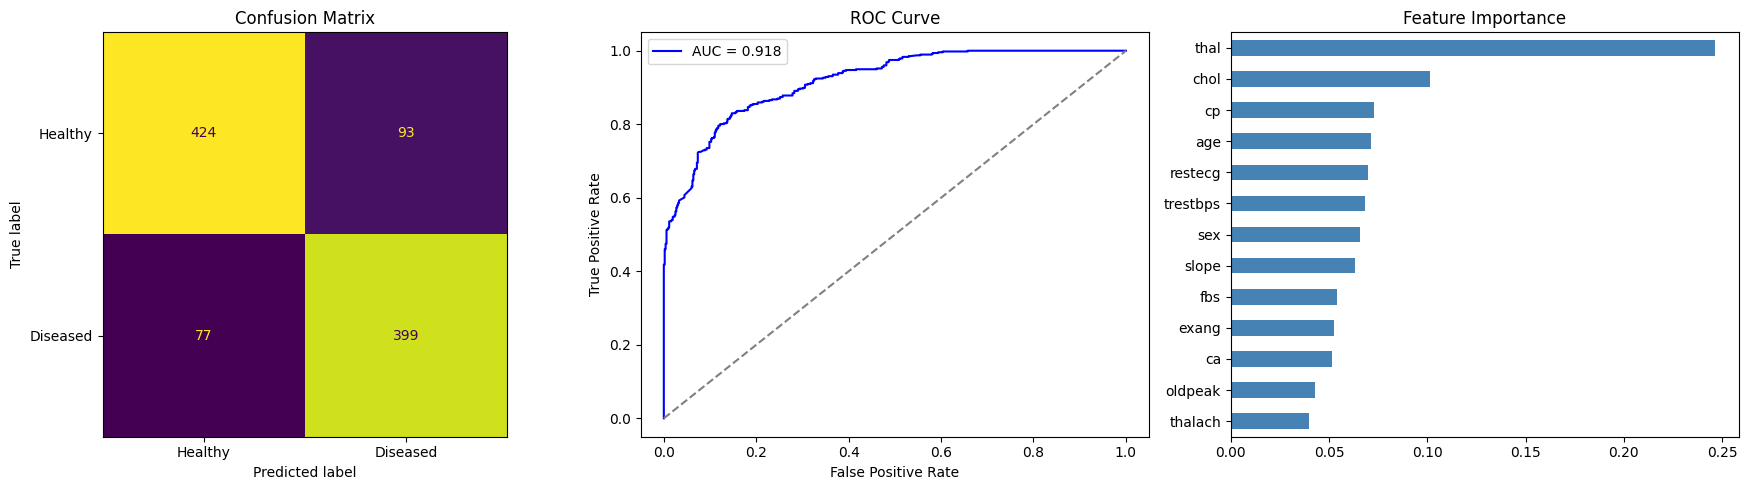

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(Y_test, Y_pred),
    display_labels=['Healthy', 'Diseased']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

# ROC Curve
fpr, tpr, _ = roc_curve(Y_test, Y_pred_prob)
axes[1].plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc_score(Y_test, Y_pred_prob):.3f}")
axes[1].plot([0,1],[0,1], '--', color='gray')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title("Feature Importance")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150)
plt.show()


## 11. Prediction Helper Function
A helper function to format raw input dictionaries into a Pandas DataFrame for prediction.


In [30]:
def predict_heart_disease(input_data: dict):
    """
    Predict heart disease risk from patient data.
    input_data: dict with keys matching feature_cols
    """
    input_df = pd.DataFrame([input_data], columns=feature_cols)
    prob     = model.predict_proba(input_df)[0][1] * 100

    print("\n" + "=" * 50)
    print("PREDICTION RESULT")
    print("=" * 50)
    print(f"Heart Attack Probability : {prob:.2f}%")

    if prob >= 75:
        print("Risk Level : 🔴 HIGH")
        print("Advice     : Consult a cardiologist immediately.")
        print("             Monitor blood pressure & cholesterol.")
        print("             Quit smoking, adopt heart-healthy diet.")
    elif prob >= 50:
        print("Risk Level : 🟡 MODERATE")
        print("Advice     : Schedule a check-up with your doctor.")
        print("             Exercise 30 mins/day, watch your diet.")
        print("             Monitor blood pressure regularly.")
    else:
        print("Risk Level : 🟢 LOW")
        print("Advice     : Maintain balanced diet & active lifestyle.")
        print("             150 mins of moderate exercise weekly.")
        print("             Regular medical check-ups recommended.")

    return prob

## 12. Sample Prediction
Testing the model with a sample patient profile.


In [31]:
sample_patient = {
    'age'     : 59,
    'sex'     : 1,
    'cp'      : 0,
    'trestbps': 164,
    'chol'    : 176,
    'fbs'     : 1,
    'restecg' : 0,
    'thalach' : 90,
    'exang'   : 0,
    'oldpeak' : 1.0,
    'slope'   : 1,
    'ca'      : 2,
    'thal'    : 1
}

# Only pass features that exist after column dropping
sample_filtered = {k: v for k, v in sample_patient.items() if k in feature_cols}
predict_heart_disease(sample_filtered)


PREDICTION RESULT
Heart Attack Probability : 59.50%
Risk Level : 🟡 MODERATE
Advice     : Schedule a check-up with your doctor.
             Exercise 30 mins/day, watch your diet.
             Monitor blood pressure regularly.


np.float64(59.50047455332648)

## 13. Exporting the Model
Saving the trained model, feature names, and performance metrics into a .pkl file for use in the Flask web application.


In [32]:
with open('heart_disease_model_v2.pkl', 'wb') as f:
    pickle.dump({
        'model'       : model,
        'features'    : feature_cols,
        'test_accuracy': round(test_acc, 3),
        'roc_auc'     : round(roc_auc_score(Y_test, Y_pred_prob), 3)
    }, f)

print("\n Model saved → heart_disease_model_v2.pkl")



 Model saved → heart_disease_model_v2.pkl


## 14. Verification
Loading the saved model to verify it was exported correctly.


In [33]:
with open('heart_disease_model_v2.pkl', 'rb') as f:
    saved = pickle.load(f)

loaded_model    = saved['model']
loaded_features = saved['features']

print(f"\nLoaded model accuracy : {saved['test_accuracy']}")
print(f"Loaded model ROC-AUC  : {saved['roc_auc']}")


Loaded model accuracy : 0.829
Loaded model ROC-AUC  : 0.918
